In [117]:
import os
import sys
import re
import random
import subprocess
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from IPython.display import display, Markdown
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    """Пытается импортировать пакет и при необходимости установить его через pip."""
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет использован fallback на sklearn NearestNeighbors.")
    print("Причина:", repr(e))


print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Sklearn:", sklearn.__version__)
print("FAISS available:", FAISS_AVAILABLE)

NumPy: 2.0.2
Pandas: 2.2.2
Sklearn: 1.6.1
FAISS available: True


In [118]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


Предметной областью является пассажирский транспорт. Разумно строить retrieval / mini-RAG из-за компактности и из-за того, что каждый транспорт содержится в отдельном документе

In [119]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Метрополитен",
        "text": (
            "Метрополитен – рельсовый внеуличный скоростной транспорт, преимущественно проходящий под землёй. "
            "В московском метро самые короткие интервалы в мире между поездами, что позволяет перевозить больше пассажиров. "
            "В метро 15 линий, считая МЦК, которые проходят через всю Москву. Здесь самый молодой парк поездов в Европе. "
            "Преимуществом метро является то, что можно добраться в любую точку Москвы, минуя пробки на дорогах. "
            "Метрополитен есть в 8 городах России: Москва, Санкт-Петербург, Нижний Новгород, Новосибирск, "
            "Казань, Екатеринбург, Самара, Волгоград. В Волгограде метротрамвай, который также считается системй метро."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Автобус",
        "text": (
            "Автобус – это вид наземного общественного транспорта, предназначенный для перевозки пассажиров "
            "по установленным маршрутам. В городских условиях автобусы оснащены поручнями, сиденьями и "
            "системами оплаты проезда. Они движутся по дорогам общего пользования, подчиняясь правилам "
            "дорожного движения и расписанию остановок. В Москве сейчас планово заменяют автобусы на электробусы."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Электробус",
        "text": (
            "Электробус – это вид наземного городского транспорта, который приводится в движение "
            "электродвигателем и питается от тяговых аккумуляторных батарей. В отличие от троллейбуса, "
            "электробусу не нужна контактная сеть, а в отличие от обычного автобуса, он не выбрасывает "
            "вредных веществ в атмосферу. Зарядка батарей обычно происходит на конечных остановках "
            "через ультрабыстрые зарядные станции или в ночное время в депо."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Троллейбус",
        "text": (
            "Троллейбус – это вид наземного городского электрического транспорта, который получает энергию "
            "от контактной сети через штанговые токоприёмники. Современные модели оснащаются функцией "
            "увеличенного автономного хода и тяговыми аккумуляторными батареями, что позволяет им "
            "преодолевать от 20 до 60 километров без подключения к проводам. "
            "Это даёт возможность объезжать препятствия, продлевать маршруты в районы без контактной сети "
            "и не прерывать движение при обрывах линии. Зарядка батарей происходит во время движения под "
            "проводами или за счёт рекуперации энергии при торможении. Такой гибридный подход сочетает "
            "экологичность и экономичность классического троллейбуса с манёвренностью электробуса, не требуя "
            "строительства дорогостоящих зарядных станций, что является превосходством троллейбуса над электробусом. "
            "В Москве осталось 3 постоянных маршрута троллейбуса. "
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Трамвай",
        "text": (
            "Трамвай – это вид рельсового наземного городского транспорта, который традиционно получает "
            "питание от контактной сети через пантограф. Современные модели всё чаще оснащаются функцией "
            "автономного хода на базе тяговых аккумуляторных батарей, суперконденсаторов или водородных "
            "топливных элементов. Это позволяет трамваю проезжать до 15–30 километров без подключения "
            "к проводам, что особенно актуально при прохождении исторических центров городов, площадей "
            "и архитектурных памятников, где контактная сеть портит визуальный облик. Автономный ход также "
            "обеспечивает бесперебойную работу при авариях на линии и упрощает обслуживание стрелочных узлов. "
            "В отличие от автобуса или троллейбуса, трамвай обладает высокой провозной способностью и "
            "движется по выделенному полотну, что делает его основой скоростного рельсового каркаса "
            "современного мегаполиса."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Пассажирский поезд",
        "text": (
            "Пассажирский поезд – это состав из вагонов, приводимый в движение локомотивом или моторными "
            "вагонами, предназначенный для перевозки людей по железнодорожным путям. В зависимости от "
            "дальности следования выделяют пригородные электропоезда, поезда дальнего следования и "
            "высокоскоростные магистрали. Современные пассажирские поезда, такие как электропоезда постоянного "
            "формирования или скоростные составы типа Сапсан, Ласточка, Финист, Иволга и Аврора, отличаются "
            "высокой плавностью хода, системами климат-контроля, герметичными межвагонными переходами "
            "и местами для зарядки гаджетов. В отличие от городского наземного транспорта, поезд движется по выделенной "
            "инфраструктуре с жёстким соблюдением графика и интервалов, обеспечивая высокую провозную способность и "
            "энергоэффективность на маршрутах средней и большой протяжённости."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Речной трамвайчик",
        "text": (
            "Речной трамвайчик – пассажирское судно малого или среднего водоизмещения, предназначенное "
            "для регулярных перевозок по внутригородским и пригородным водным маршрутам. В отличие от "
            "крупных круизных теплоходов, речные трамвайчики обладают высокой манёвренностью, малой осадкой "
            "и способностью швартоваться у причалов и набережных. В Москве речные трамвайчики ходят на электрической тяге. "
            "Такие суда работают круглогодично, в том числе в период ледостава, интегрируются в единую "
            "билетную систему городского транспорта. Речной трамвайчик позволяет разгрузить автомобильные магистрали "
            "в часы пик и служит не только утилитарным средством передвижения, но и популярным экскурсионным "
            "маршрутом для осмотра городских достопримечательностей с воды. В Москве планируется "
            "запустить 15 маршрутов речных трамвайчиков."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Самолёт",
        "text": (
            "Пассажирский самолёт – это самый быстрый способ преодолеть большие расстояния, превращающий "
            "многочасовые поездки в комфортный перелёт длительностью несколько часов. Современные лайнеры "
            "оборудованы удобными креслами с регулируемыми спинками, индивидуальными экранами мультимедиа "
            "и розетками для зарядки устройств. На борту пассажирам предлагают питание, напитки и доступ "
            "к Wi-Fi для работы или развлечений. Просторные багажные полки вмещают ручную кладь, а основной "
            "багаж сдаётся при регистрации и выдаётся по прибытии. Герметичный салон и системы "
            "шумоподавления создают спокойную атмосферу, позволяя пассажиру поспать, почитать или посмотреть "
            "фильм, пока лайнер на высоте десяти километров стремительно приближается к месту назначения."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Канатная дорога",
        "text": (
            "Канатная дорога – вид внеуличного транспорта, где кабины или кресла перемещаются по несущему "
            "тросу над поверхностью земли на высоких опорах. В отличие от фуникулёра, канатная дорога идёт "
            "по воздуху, что позволяет ей пересекать реки, овраги и плотную застройку по кратчайшей прямой "
            "без строительства дорогостоящих мостов или тоннелей. Посадка происходит очень быстро, интервал "
            "движения кабин составляет всего 30–60 секунд, а пассажир в это время наслаждается панорамным "
            "видом на город или природный ландшафт. Главные преимущества канатки перед фуникулёром – это "
            "минимальное изъятие земли под инфраструктуру, низкий уровень шума и способность преодолевать "
            "водные преграды, однако при сильном ветре её работу могут временно приостанавливать ради безопасности."
            "В России канатные дороги пользуются популярностью на горных, речных, парковых и пляжных местностях."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Фуникулёр",
        "text": (
            "Фуникулёр – рельсовый транспорт с канатной тягой, вагоны которого перемещаются по крутому "
            "склону за счёт стального троса из стационарного машинного отделения. В отличие от канатной "
            "дороги, фуникулёр жёстко закреплён на рельсах, часто с зубчатой передачей, что гарантирует "
            "абсолютную устойчивость и безопасность даже на уклонах до 45 градусов и в условиях гололёда. "
            "Он движется по земле, а не по воздуху, поэтому ему не страшен сильный ветер, из-за которого "
            "канатную дорогу пришлось бы остановить. Главные преимущества фуникулёра – это высокая "
            "провозная способность, стабильность работы в любую погоду и способность служить надёжным "
            "лифтом между верхней и нижней частями города, хотя для его строительства требуется больше "
            "земляных работ и подготовки трассы. В России всего 3 фуникулёра: во Владивостоке, Сочи и Нижнем Новгороде."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Круизный лайнер",
        "text": (
            "Круизный лайнер – это крупное пассажирское судно, представляющее собой плавучий курорт с "
            "ресторанами, бассейнами, театрами и спортивными площадками на борту. Путешествие на лайнере "
            "позволяет посетить несколько стран или городов за один рейс, при этом багаж остаётся в каюте, "
            "а отель следует за пассажиром. Для удобства гостей на борту действует система всё включено, "
            "работают аниматоры, спа-центры и детские клубы. Пассажиру не нужно думать о логистике, "
            "трансферах и поиске жилья – достаточно выбрать маршрут и наслаждаться видами с верхней палубы."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Такси",
        "text": (
            "Такси – индивидуальный вид городского транспорта, позволяющий добраться от двери до двери "
            "без привязки к расписанию и маршрутам общественного транспорта. Современные агрегаторы делают "
            "поездку максимально простой: пассажир указывает адрес в приложении, видит стоимость заранее "
            "и отслеживает прибытие машины на карте. Оплата происходит безналично с привязанной карты, "
            "а водитель уже знает точку назначения. Такси удобно для поездок с багажом, в непогоду, ночью "
            "или в незнакомом городе, когда важно быстро и без пересадок оказаться в нужном месте."
        ),
    },
]


benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Сколько линий метро в Москве?",
        "relevant_doc_ids": ["doc_01"],
    },
    {
        "query_id": "q02",
        "query": "Как происходит зарядка батареи у электробуса?",
        "relevant_doc_ids": ["doc_04"],
    },
    {
        "query_id": "q03",
        "query": "Сколько фуникулёров в России?",
        "relevant_doc_ids": ["doc_10"],
    },
    {
        "query_id": "q04",
        "query": "Чем речной трамвайчик отличается от других видов транспорта?",
        "relevant_doc_ids": ["doc_07"],
    },
    {
        "query_id": "q05",
        "query": "Почему не везде присутствует контактная сеть у трамвая",
        "relevant_doc_ids": ["doc_05"],
    },
    {
        "query_id": "q06",
        "query": "Какие типы скоростных поездов ходят на железной дороге?",
        "relevant_doc_ids": ["doc_06"],
    },
    {
        "query_id": "q07",
        "query": "Что предлагают пассажирам на борту самолёта?",
        "relevant_doc_ids": ["doc_08"],
    },
    {
        "query_id": "q08",
        "query": "На какой вид транспорта заменяют автобусы в Москве?",
        "relevant_doc_ids": ["doc_02"],
    },
    {
        "query_id": "q09",
        "query": "Как движутся кабинки на канатной дороге?",
        "relevant_doc_ids": ["doc_09"],
    },
    {
        "query_id": "q10",
        "query": "Чем электробус отличается от троллейбуса?",
        "relevant_doc_ids": ["doc_03"],
    },
    {
        "query_id": "q11",
        "query": "Что позволяет сделать путешествие на лайнере?",
        "relevant_doc_ids": ["doc_11"],
    },
    {
        "query_id": "q12",
        "query": "Что делает пассажир, чтобы заказать такси?",
        "relevant_doc_ids": ["doc_12"],
    },
]

docs_df = pd.DataFrame(documents)
print("Размер корпуса:", len(docs_df))
display(docs_df[["doc_id", "title"]])

Размер корпуса: 12


,doc_id,title
0,doc_01,Метрополитен
1,doc_02,Автобус
2,doc_03,Электробус
3,doc_04,Троллейбус
4,doc_05,Трамвай
5,doc_06,Пассажирский поезд
6,doc_07,Речной трамвайчик
7,doc_08,Самолёт
8,doc_09,Канатная дорога
9,doc_10,Фуникулёр


Для небольших документов такие параметры создают достаточное количество гранулярных фрагментов, что повышает шанс точного совпадения запроса с нужным куском текста при семантическом поиске

In [120]:
def chunk_text(text: str, chunk_size: int = 40, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


In [121]:
# Единый интерфейс для двух вариантов векторизации: dense embeddings и fallback.
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(model_name=model_name, device=device)
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Ноутбук останется рабочим,")
        print("но это уже не полноценные dense embeddings.")
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [122]:
# Простая функция чанкинга по словам.
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 28,
    overlap: int = 8,
) -> pd.DataFrame:
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)


chunks_df = build_chunks_dataframe(documents, chunk_size=28, overlap=8)

print("Количество чанков:", len(chunks_df))
display(chunks_df.head(10))

Количество чанков: 54


,doc_id,title,chunk_id,chunk_text,n_words
0,doc_01,Метрополитен,0,Метрополитен – рельсовый внеуличный скоростной...,28
1,doc_01,Метрополитен,1,что позволяет перевозить больше пассажиров. В ...,28
2,doc_01,Метрополитен,2,поездов в Европе. Преимуществом метро является...,28
3,doc_01,Метрополитен,3,"в 8 городах России: Москва, Санкт-Петербург, Н...",21
4,doc_02,Автобус,0,Автобус – это вид наземного общественного тран...,28
5,doc_02,Автобус,1,сиденьями и системами оплаты проезда. Они движ...,26
6,doc_03,Электробус,0,Электробус – это вид наземного городского тран...,28
7,doc_03,Электробус,1,"от троллейбуса, электробусу не нужна контактна...",28
8,doc_03,Электробус,2,Зарядка батарей обычно происходит на конечных ...,17
9,doc_04,Троллейбус,0,Троллейбус – это вид наземного городского элек...,28


In [123]:
class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows


@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )

def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered

In [124]:
baseline_chunk_size = 28
baseline_overlap = 8

artifacts = build_retriever(
    documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

# Посмотрим несколько контрольных запросов вручную.
sample_queries = [
    "В каких городах есть метро?",
    "Чем фуникулёр отличается от канатной дороги",
    "Какой транспорт самый экологичный?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 54


,doc_id,title,chunk_id,chunk_idx,chunk_text
0,doc_01,Метрополитен,doc_01_chunk_0,0,Метрополитен – рельсовый внеуличный скоростной...
1,doc_01,Метрополитен,doc_01_chunk_1,1,что позволяет перевозить больше пассажиров. В ...
2,doc_01,Метрополитен,doc_01_chunk_2,2,поездов в Европе. Преимуществом метро является...
3,doc_01,Метрополитен,doc_01_chunk_3,3,"в 8 городах России: Москва, Санкт-Петербург, Н..."
4,doc_02,Автобус,doc_02_chunk_0,0,Автобус – это вид наземного общественного тран...


### Запрос: В каких городах есть метро?

,rank,score,doc_id,title,chunk_text
0,1,0.602511,doc_01,Метрополитен,Метрополитен – рельсовый внеуличный скоростной...
1,2,0.582819,doc_07,Речной трамвайчик,билетную систему городского транспорта. Речной...
2,3,0.563107,doc_01,Метрополитен,поездов в Европе. Преимуществом метро является...


### Запрос: Чем фуникулёр отличается от канатной дороги

,rank,score,doc_id,title,chunk_text
0,1,0.706809,doc_10,Фуникулёр,Фуникулёр – рельсовый транспорт с канатной тяг...
1,2,0.663811,doc_09,Канатная дорога,"Канатная дорога – вид внеуличного транспорта, ..."
2,3,0.657266,doc_09,Канатная дорога,"В отличие от фуникулёра, канатная дорога идёт ..."


### Запрос: Какой транспорт самый экологичный?

,rank,score,doc_id,title,chunk_text
0,1,0.531405,doc_07,Речной трамвайчик,билетную систему городского транспорта. Речной...
1,2,0.528579,doc_11,Круизный лайнер,"нужно думать о логистике, трансферах и поиске ..."
2,3,0.498759,doc_04,Троллейбус,и экономичность классического троллейбуса с ма...


In [ ]:
def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))

    # Handle case where relevant_doc_ids is empty to avoid ZeroDivisionError
    if not relevant_doc_ids:
        recall = 0.0
    else:
        recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)


# Прогоняем весь benchmark и считаем метрики для baseline-конфигурации.
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

retrieval_df = baseline_eval_k3[['query', 'relevant_doc_ids', 'predicted_doc_ids', 'hit@3']].copy()
retrieval_df.rename(columns={
    'relevant_doc_ids': 'expected_source',
    'predicted_doc_ids': 'retrieved_sources',
    'hit@3': 'hit_at_k'
}, inplace=True)
retrieval_df.to_csv('artifacts/retrieval_eval.csv', index=False)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Сколько линий метро в Москве?,doc_01,doc_01,1,1.0,1.0,1
1,q02,Как происходит зарядка батареи у электробуса?,doc_04,"doc_04, doc_03",1,1.0,1.0,1
2,q03,Сколько фуникулёров в России?,doc_10,"doc_10, doc_01",1,1.0,1.0,1
3,q04,Чем речной трамвайчик отличается от других вид...,doc_07,doc_07,1,1.0,1.0,1
4,q05,Почему не везде присутствует контактная сеть у...,doc_05,"doc_05, doc_06, doc_03",1,1.0,1.0,1
5,q06,Какие типы скоростных поездов ходят на железно...,doc_06,doc_06,1,1.0,1.0,1
6,q07,Что предлагают пассажирам на борту самолёта?,doc_08,"doc_08, doc_11",1,1.0,1.0,1
7,q08,На какой вид транспорта заменяют автобусы в Мо...,doc_02,"doc_02, doc_01, doc_04",1,1.0,1.0,1
8,q09,Как движутся кабинки на канатной дороге?,doc_09,"doc_09, doc_10",1,1.0,1.0,1
9,q10,Чем электробус отличается от троллейбуса?,doc_03,"doc_03, doc_04",1,1.0,1.0,1


,metric,value
0,mean_hit@3,1.0
1,mean_recall@3,1.0
2,mean_MRR@3,1.0


🔹 Оценка для chunk_size=28...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
🔹 Оценка для chunk_size=45...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


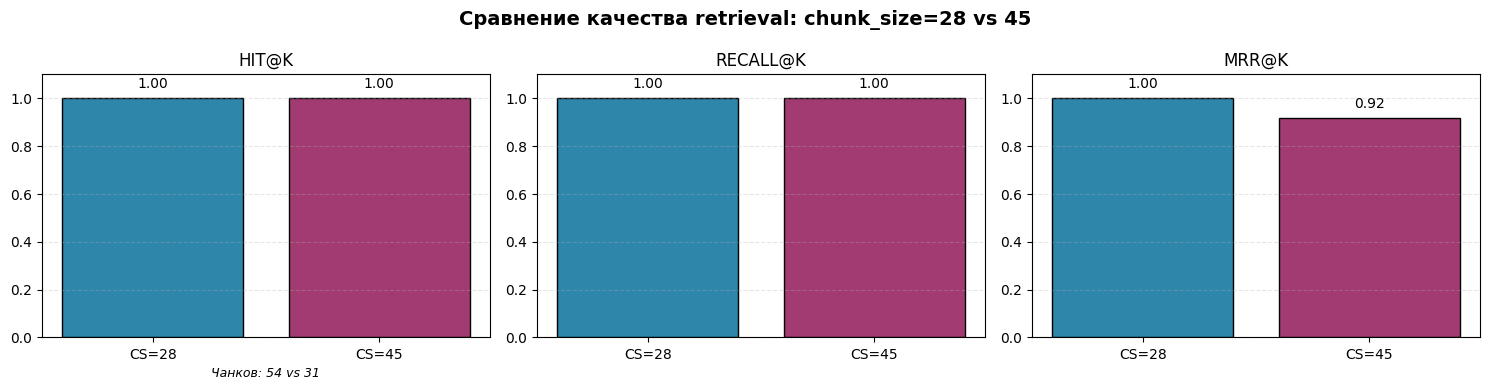

,chunk_size,Hit@3,Recall@3,MRR@3,n_chunks
0,28,1.0,1.0,1.000000,54
1,45,1.0,1.0,0.916667,31


In [ ]:
chunk_sizes = [28, 45]
overlap = 8
top_k = 3

def evaluate_retrieval_quality(chunk_size: int, overlap: int, top_k: int,
                              benchmark: list, documents: list, device) -> dict:
    """Оценивает качество retrieval для заданных параметров чанкинга."""
    arts = build_retriever(documents, chunk_size=chunk_size, overlap=overlap, device=device)
    results = []

    for item in benchmark:
        res_df = search_chunks(item["query"], artifacts=arts, top_k=top_k)
        retrieved = set(res_df["doc_id"].unique())
        relevant = set(item["relevant_doc_ids"])

        hit = int(bool(retrieved & relevant))
        recall = len(retrieved & relevant) / len(relevant) if relevant else 0

        # MRR
        mrr = 0.0
        for rank, doc_id in enumerate(unique_doc_order(res_df), start=1):
            if doc_id in relevant:
                mrr = 1.0 / rank
                break

        results.append({"hit": hit, "recall": recall, "mrr": mrr})

    return {
        "hit@k": np.mean([r["hit"] for r in results]),
        "recall@k": np.mean([r["recall"] for r in results]),
        "mrr@k": np.mean([r["mrr"] for r in results]),
        "n_chunks": len(arts.chunks_df)
    }

# Запускаем оценку для обоих вариантов
metrics = {}
for cs in chunk_sizes:
    print(f"🔹 Оценка для chunk_size={cs}...")
    metrics[cs] = evaluate_retrieval_quality(cs, overlap, top_k, benchmark_queries, documents, DEVICE)

# 📊 Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Сравнение качества retrieval: chunk_size=28 vs 45", fontsize=14, fontweight='bold')

metric_names = ["hit@k", "recall@k", "mrr@k"]
colors = ['#2E86AB', '#A23B72']

for idx, metric in enumerate(metric_names):
    values = [metrics[cs][metric] for cs in chunk_sizes]
    bars = axes[idx].bar([f"CS={cs}" for cs in chunk_sizes], values, color=colors, edgecolor='black')
    axes[idx].set_title(metric.upper())
    axes[idx].set_ylim(0, 1.1)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.3)

    # Подписываем значения на столбцах
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                      f"{val:.2f}", ha='center', va='bottom', fontsize=10)

# Добавляем информацию о количестве чанков
axes[0].text(0.5, -0.15, f"Чанков: {metrics[28]['n_chunks']} vs {metrics[45]['n_chunks']}",
            ha='center', transform=axes[0].transAxes, fontsize=9, style='italic')

plt.tight_layout()
plt.savefig("artifacts/retrieval_quality_plot.png", dpi=150, bbox_inches='tight')
plt.show()

# Таблица с результатами
from IPython.display import display, Markdown
import pandas as pd

summary_df = pd.DataFrame({
    "chunk_size": chunk_sizes,
    "Hit@3": [metrics[cs]["hit@k"] for cs in chunk_sizes],
    "Recall@3": [metrics[cs]["recall@k"] for cs in chunk_sizes],
    "MRR@3": [metrics[cs]["mrr@k"] for cs in chunk_sizes],
    "n_chunks": [metrics[cs]["n_chunks"] for cs in chunk_sizes]
})
display(summary_df)

In [ ]:
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_13",
        "title": "Маршрутка",
        "text": (
            "Маршрутка – это вид городского и пригородного общественного транспорта, представляющий собой "
            "микроавтобус или автобус малого класса, работающий на фиксированном маршруте. В отличие от "
            "обычного автобуса, маршрутка останавливается по требованию пассажира практически в любом месте "
            "по пути следования, а не только на оборудованных остановках. Маршрутки преимущественно ходят "
            "на тех маршрутах, где маленький пассажиропоток. В крупных городах они встречаются реже, чем "
            "общественный транспорт большей вместимости."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Метротрамвай",
        "text": (
            "Метротрамвай – рельсовый скоростной транспорт, у которого преимущественно обособленная трасса. "
            "Метротрамвай, как метро, только вместо поездов ходят трамваи. Трамваи в метротраме отличаются от "
            "стандартных: они длиннее, больше вместимости, с двумя кабинами для водителей, а также с дверьми с двух сторон. "
            "Единственный метротрамвай России расположен в Волгограде, а в скором времени появится в Красноярске и Челябинске."
        ),
    },
]

updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [
    "В каких городах появится метротрам?",
    "В скольких городах есть метро?"
]


artifacts_updated = build_retriever(
    updated_documents,
    chunk_size=28,
    overlap=8,
    device=DEVICE
)


res12: Dict[str, List[str]] = {}
for query in new_queries:
    res: pd.DataFrame = search_chunks(query, artifacts, top_k=3)
    res12[query] = res["doc_id"].tolist()
    print(f"  '{query}'")
    print(f"  Найдено: {res['doc_id'].tolist()}")


res14: Dict[str, List[str]] = {}
for query in new_queries:
    res = search_chunks(query, artifacts_updated, top_k=3)
    res14[query] = res["doc_id"].tolist()
    print(f"  '{query}'")
    print(f"  Найдено: {res['doc_id'].tolist()}")

print("\nСравнение:")
comparison_rows = []
for query in new_queries:
    comparison_rows.append({
        "query": query,
        "before_retrieved_sources": ", ".join(res12[query]),
        "after_retrieved_sources": ", ".join(res14[query]),
        "changed": res12[query] != res14[query],
    })

retrieval_before_after_update = pd.DataFrame(comparison_rows)
display(retrieval_before_after_update)


retrieval_before_after_update.to_csv('artifacts/retrieval_before_after_update.csv', index=False)

,doc_id,title
0,doc_13,Маршрутка
1,doc_14,Метротрамвай


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
  'В каких городах появится метротрам?'
  Найдено: ['doc_07', 'doc_01', 'doc_01']
  'В скольких городах есть метро?'
  Найдено: ['doc_01', 'doc_01', 'doc_01']
  'В каких городах появится метротрам?'
  Найдено: ['doc_07', 'doc_14', 'doc_01']
  'В скольких городах есть метро?'
  Найдено: ['doc_01', 'doc_01', 'doc_01']

Сравнение:


,query,before_retrieved_sources,after_retrieved_sources,changed
0,В каких городах появится метротрам?,"doc_07, doc_01, doc_01","doc_07, doc_14, doc_01",True
1,В скольких городах есть метро?,"doc_01, doc_01, doc_01","doc_01, doc_01, doc_01",False


In [128]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }
baseline_example = answer_without_retrieval(
    "Сколько километров может проехать троллейбус на автономном ходе?",
    documents,
)

display(pd.DataFrame([baseline_example]))

,answer,selected_doc_id,selected_title,score
0,Троллейбус – это вид наземного городского элек...,doc_04,Троллейбус,0.040354


In [129]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

def search_chunks_deduplicated(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k * 3)  # Берем с запасом

    # Дедупликация по doc_id
    seen_docs = set()
    unique_results = []

    for score, idx in zip(scores[0], indices[0]):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        doc_id = chunk_row["doc_id"]

        if doc_id not in seen_docs:
            seen_docs.add(doc_id)
            unique_results.append(
                {
                    "rank": len(unique_results) + 1,
                    "score": float(score),
                    "doc_id": doc_id,
                    "title": chunk_row["title"],
                    "chunk_id": chunk_row["chunk_id"],
                    "chunk_text": chunk_row["chunk_text"],
                }
            )

        if len(unique_results) >= top_k:
            break

    return pd.DataFrame(unique_results)


def build_context_from_retrieval(query: str, artifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k) # Changed artifacts=artifacts_updated to artifacts=artifacts
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

baseline_example = answer_without_retrieval(
    "Сколько километров может проехать троллейбус на автономном ходе?",
    documents,
)

query = "На какой траспорт заменят автобусы в Москве?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts_updated, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)


def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)


answer_example = generate_answer_from_context(query, context)
print(answer_example)

### Запрос: На какой траспорт заменят автобусы в Москве?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.815440,doc_02,Автобус,doc_02_chunk_1,сиденьями и системами оплаты проезда. Они движ...
1,2,0.689271,doc_04,Троллейбус,doc_04_chunk_4,и экономичность классического троллейбуса с ма...
2,3,0.676384,doc_01,Метрополитен,doc_01_chunk_2,поездов в Европе. Преимуществом метро является...


[Источник: doc_02 | Автобус | score=0.8154]
сиденьями и системами оплаты проезда. Они движутся по дорогам общего пользования, подчиняясь правилам дорожного движения и расписанию остановок. В Москве сейчас планово заменяют автобусы на электробусы.

[Источник: doc_04 | Троллейбус | score=0.6893]
и экономичность классического троллейбуса с манёвренностью электробуса, не требуя строительства дорогостоящих зарядных станций, что является превосходством троллейбуса над электробусом. В Москве осталось 3 постоянных маршрута троллейбуса.

[Источник: doc_01 | Метрополитен | score=0.6764]
поездов в Европе. Преимуществом метро является то, что можно добраться в любую точку Москвы, минуя пробки на дорогах. Метрополитен есть в 8 городах России: Москва, Санкт-Петербург, Нижний Новгород,
В Москве сейчас планово заменяют автобусы на электробусы. В Москве осталось 3 постоянных маршрута троллейбуса.


In [137]:
def mini_rag_answer(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts_updated, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }
rag_result = mini_rag_answer(
    "Что такое метротрамвай?",
    artifacts=artifacts_updated,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

rag_result = mini_rag_answer(
    "Что такое пассажирский самолёт?",
    artifacts=artifacts_updated,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Что такое метротрамвай?

**Ответ:** Метротрамвай, как метро, только вместо поездов ходят трамваи. Метротрамвай – рельсовый скоростной транспорт, у которого преимущественно обособленная трасса.

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.671482,doc_14,Метротрамвай,doc_14_chunk_0,"Метротрамвай – рельсовый скоростной транспорт,..."
1,2,0.664862,doc_07,Речной трамвайчик,doc_07_chunk_3,билетную систему городского транспорта. Речной...
2,3,0.659882,doc_05,Трамвай,doc_05_chunk_0,Трамвай – это вид рельсового наземного городск...


### Вопрос: Что такое пассажирский самолёт?

**Ответ:** Пассажирский самолёт – это самый быстрый способ преодолеть большие расстояния, превращающий многочасовые поездки в комфортный перелёт длительностью несколько часов.

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.650893,doc_08,Самолёт,doc_08_chunk_0,Пассажирский самолёт – это самый быстрый спосо...
1,2,0.572325,doc_08,Самолёт,doc_08_chunk_1,лайнеры оборудованы удобными креслами с регули...
2,3,0.562361,doc_11,Круизный лайнер,doc_11_chunk_1,Путешествие на лайнере позволяет посетить неск...


In [131]:
baseline_n_chunks = len(artifacts.chunks_df)

baseline_row = pd.DataFrame({
    "chunk_size": [baseline_chunk_size],
    "Hit@3": [summary_k3[summary_k3["metric"] == "mean_hit@3"]["value"].iloc[0]],
    "Recall@3": [summary_k3[summary_k3["metric"] == "mean_recall@3"]["value"].iloc[0]],
    "MRR@3": [summary_k3[summary_k3["metric"] == "mean_MRR@3"]["value"].iloc[0]],
    "n_chunks": [baseline_n_chunks]
})

combined_summary_df = pd.concat([baseline_row, summary_df], ignore_index=True)
display(combined_summary_df)

,chunk_size,Hit@3,Recall@3,MRR@3,n_chunks
0,28,1.0,1.0,1.000000,54
1,28,1.0,1.0,1.000000,54
2,45,1.0,1.0,0.916667,31


In [ ]:
rag_results_list = []
demo_queries = [
    "На что заменяют автобусы в Москве?",
    "Какой транспорт может заряжаться на ходу?",
    "В каких городах есть метрополитен?",
    "Чем фуникулёр отличается от канатной дороги?",
    "Где появится метротрамвай в будущем?"
]

for q in demo_queries:
    result = mini_rag_answer(q, artifacts=artifacts, top_k=3)

    sources_str = ", ".join([f"{row['title']} ({row['doc_id']})" for _, row in result['sources'].iterrows()])

    rag_results_list.append({
        'question': result['query'],
        'answer': result['answer'],
        'retrieved_sources': sources_str
    })

rag_df = pd.DataFrame(rag_results_list)
rag_df.to_csv('artifacts/rag_examples.csv', index=False, encoding='utf-8-sig')

Где-то ответ верный, но с информацией не по теме, где-то предложение дублируется с середины, где-то ответ неправильный, а где-то он не найден. В данных случаях неправильный retrieval, состав контекста, формулировка вопроса и неполнота базы знаний

In [144]:
test_queries = [
    "На какой транспорт планово заменяют автобусы в Москве?",

    "Как заряжается троллейбус, когда нет проводов?",

    "В каких городах России есть метрополитен?",

    "Сколько стоит проезд в метрополитене?",

    "Почему в Волгограде есть и метро, и метротрам?"
]


error_analysis = []

for q in test_queries:
    print(f"\n Запрос: {q}")
    res = mini_rag_answer(q, artifacts=artifacts, top_k=3)

    print(f"Ответ: {res['answer']}")
    print("Источники:", [row['title'] for _, row in res['sources'].iterrows()])
    print("-" * 40)


 Запрос: На какой транспорт планово заменяют автобусы в Москве?
Ответ: В Москве сейчас планово заменяют автобусы на электробусы. В Москве осталось 3 постоянных маршрута троллейбуса.
Источники: ['Автобус', 'Метрополитен', 'Троллейбус']
----------------------------------------

 Запрос: Как заряжается троллейбус, когда нет проводов?
Ответ: Троллейбус – это вид наземного городского электрического транспорта, который получает энергию от контактной сети через штанговые токоприёмники.
Источники: ['Троллейбус', 'Электробус', 'Электробус']
----------------------------------------

 Запрос: В каких городах России есть метрополитен?
Ответ: Метрополитен есть в 8 городах России: Москва, Санкт-Петербург, Нижний Новгород, в 8 городах России: Москва, Санкт-Петербург, Нижний Новгород, Новосибирск, Казань, Екатеринбург, Самара, Волгоград.
Источники: ['Метрополитен', 'Метрополитен', 'Метротрамвай']
----------------------------------------

 Запрос: Сколько стоит проезд в метрополитене?
Ответ: В найденн